## Authors:
- **Sebastián Kay Conde Lorenzo**
- **Carlos Antonio Sánchez-Beato Alonso**

## How to use? (Unix/Mac OS):
1. (using ```uv``` [recommended! ```uv``` is really cool]):
    1. Create a virtual enviroment for the project with ```uv venv```
    2. Install the necessary packages with ```uv pip install numpy matplotlib pandas scipy````
    3. Install the necessary packages for running a jupyter notebook (vscode prompts this automatically!)
2. Extract the dataset using ```tar -xvzf community_images.tar.gz```
    * e***x***tract...
    * ***v***erbose...
    * use g***z***ip...
    * ***f***ile...

## Responsible AI usage:
We (the authors) claim that no AI was used in the realization of this code and explanations (markdown cells), unless otherwise specified and documented.

# Parameters estimation and Bayesian Inference

The goal of the labwork is to study parameters estimation based on some artificial or real dataset. For this work, the considered methods can be the method of moments, maximum likelihood or Bayesian inference.


## Part I: [In the rain](https://www.youtube.com/watch?v=6GB3_O9-iEw) 
We consider the following dataset: a record of of the rainfall in Seattle for many different days. We will modelize these data using the Gamma distribution.

In [1]:
# list of imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

The Seattle Weather dataset contains the following columns (observations of random variables):
1. **Precipitation**: Measured in *milimiters* (this is a height, by the way. According to the internet, no matter the surface the water level will always raise to the same height).
2. **Temp max**: Maximum temperature reached. In *Celsius* (we can know this by looking at the scale of the numbers, unless Seattle is crazy cold...)
3. **Temp min**: Minimum temperature reached. In *Celsius*.
4. **Wind**: Modulus of the velocity of the wind. In *meters per second*. We figured this out with a quick Google search.
5. **Weather**: Cualitative description of the weather. It can be "rain", "fog", "drizzle", "snow" or "sun".

By nature of the dataset, the observations are independent and identically distributed.

number of samples =  1461


<ipython-input-11-edc226a28d05>:12: MatplotlibDeprecationWarning: The width parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(width) instead.
  plt.tight_layout()
<ipython-input-11-edc226a28d05>:12: MatplotlibDeprecationWarning: The height parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(height) instead.
  plt.tight_layout()
<ipython-input-11-edc226a28d05>:12: MatplotlibDeprecationWarning: The x parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(x) instead.
  plt.tight_layout()
<ipython-input-11-edc226a28d05>:12: MatplotlibDeprecationWarning: The y parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(y) instead.
  plt.tight_layout()


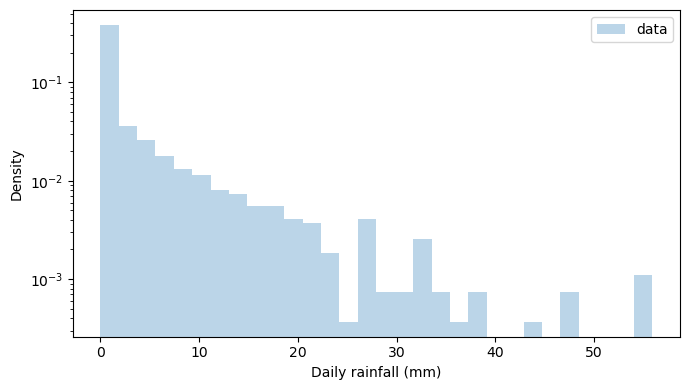

In [11]:
data = pd.read_csv('seattle-weather.xls')
rain = data["precipitation"].dropna()
print("number of samples = ",rain.size)

# plot an histogram of the dataset 
plt.figure(figsize=(7,4))
plt.hist(rain, bins=30, density=True, alpha=0.3, label="data")
plt.yscale('log')
plt.xlabel("Daily rainfall (mm)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

Realize the following tasks:
  1. In order to focus only on the rainfall, what should you do to the dataset ?
  2. Compute the mean of precipitation and its variance.
  3. We want to modelize the data by a Gamma distribution. Using the method of moments, compute an estimate of the Gamma distribution's parameters that fits the data.
  4. In order to get an estimate of the error commited on the parameters, perform a bootstrap using a realization of $n=10000$ Gamma distributed number to estimate the mean and the variance of the estimator.
  5. Give a confidence interval of 95% for the estimation of the parameters.

### Task 1
<span style="color:green">***ACABADA***</span>

In order to focus only on the rainfall, we should drop the rest of the columns of the dataset. We should also verify if there are any NaN (*Not a Number*) values. If so, we would impute the missing values. However, we see there are no such values in the precipitation column.


In [4]:
rain = data["precipitation"]
rain.isna().sum()

np.int64(0)

### Task 2

<span style="color:green">***ACABADA***</span>

Since rain is a pandas Series object (easy to check with ```type(rain)```), then we can use the built-in methods for this class.
**Note:** The returned values of this methods are of type ```np.float64``` (again, easy to check).

<span style="color:orange">There are two methods that can be usefull:</span>:

1. ```.mean()```: Computes the sample mean (not population mean). This is the unbiased estimator $\bar{X_n} = \frac{1}{n}\sum_{i=1}^n X_i$ for the population mean.
2. ```.var()```: Computes the sample variance. This is the unbiased estimator $s_c^2 = \frac{1}{n-1}\sum_{i=1}^n (X_i - \bar{X_n})^2$


<span style="color:orange">We may think of our data as a sample of the random variable given by the weather on seattle at any time. Thus, we can compute the mean of the precipitacion data as a realization of the mean estimator, and the same with the variance. For the variance, we will use the estimator</span>

$$
s^2 = \frac{1}{n}\sum_{i=1}^n (X_i - \mu)^2.
$$
because this will allow us to write the estimators computed with the moments method in convenient terms. In pandas, this is just ```.var(ddof=0)```.

In [6]:
rain_mean = rain.mean() 
rain_var = rain.var(ddof=0)

print(f"The estimated mean of the precipitation is: {rain_mean}.")
print(f"The estimated variance of the precipitation is: {rain_var}.")

The estimated mean of the precipitation is: 3.02943189596167.
The estimated variance of the precipitation is: 44.5944520386541.


### Task 3

<span style="color:green">***ACABADA***</span>

Recall the the Gamma distribution has a probability density function (PDF):

$$
p(x) = x^{\alpha - 1} \frac{\lambda^\alpha \mathrm{e}^{-\lambda x}}{\Gamma(\alpha)}; x \in [0, \infty),
$$

therefore, it has only two parameters: $\alpha$ and $\lambda$. (Note: There are other equivalent forms of the Gamma distribution, and other naming conventions for the parameters; at least according to [Wikipedia](https://en.wikipedia.org/wiki/Gamma_distribution)).

Let $\mu_1$ and $\mu_2$ be the moments of the sample. Since we know from class the moments of the Gamma distribution, $\Gamma(\alpha, \lambda)$, we want that:

$$
\begin{align*}
\mu_1 = \mathbb{E}[X] &= \frac{\alpha}{\lambda}, \hspace{0.5cm}
\mu_2 = \mathbb{E}[X^2] = \frac{\alpha(\alpha + 1)}{\lambda^2},
\end{align*}
$$

so we want to solve the following system on $\alpha$ and $\lambda$:

$$
\begin{cases}
\alpha = \lambda\mu_1\\
\alpha^2+\alpha=\lambda^2\mu_2
\end{cases}
$$

By substracting the second ecuation to the first one, if follows easilly that the solution is given by the estimators:

$$
\begin{align*}
\hat{\lambda} &= \frac{\mu_1}{\mu_2 - \mu_1^2},\\
\hat{\alpha} &= \frac{\mu_1^2}{\mu_2 - \mu_1^2}.
\end{align*}
$$

But $\mu_1=\bar{X_n}$ and $\mu_2 - \mu_1^2 = s^2$. So we have the estimators:
$$
\begin{align*}
\hat{\lambda} &= \frac{\bar{X_n}}{s^2},\\
\hat{\alpha} &= \frac{\bar{X_n}^2}{s^2}.
\end{align*}
$$
To compute $\mu_1$ and $\mu_2$ in pandas we use the mean and variance computed in the previous task.

The estimated value of λ through the moments method is 0.06793293240459113.
The estimated value of α through the moments method is 0.20579819221267648.


<ipython-input-9-c4e42b7d1531>:20: MatplotlibDeprecationWarning: The width parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(width) instead.
  plt.tight_layout()
<ipython-input-9-c4e42b7d1531>:20: MatplotlibDeprecationWarning: The height parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(height) instead.
  plt.tight_layout()
<ipython-input-9-c4e42b7d1531>:20: MatplotlibDeprecationWarning: The x parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(x) instead.
  plt.tight_layout()
<ipython-input-9-c4e42b7d1531>:20: MatplotlibDeprecationWarning: The y parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(y) instead.
  plt.tight_layout()


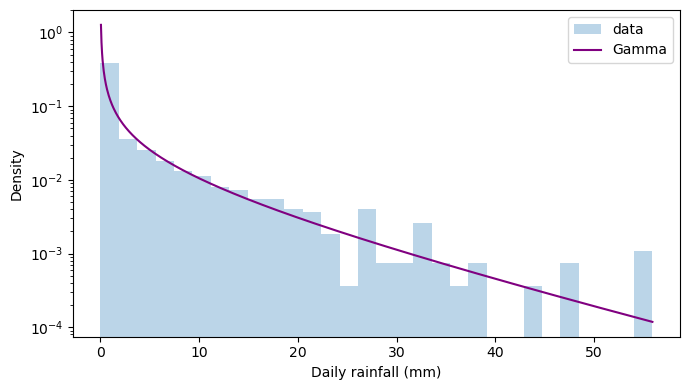

In [9]:
pop_lambda = rain_mean/rain_var
pop_alpha = (rain_mean**2)/rain_var

print(f"The estimated value of λ through the moments method is {pop_lambda}.")
print(f"The estimated value of α through the moments method is {pop_alpha}.")

# Let's plot the Gamma distribution with these parameters (over the histogram) 
# to see how well it fits the empirical distribution
plt.figure(figsize=(7,4))
plt.hist(rain, bins=30, density=True, alpha=0.3, label="data")

x_gamma = np.linspace(0, rain.max(), 1000)
p_x_gamma = gamma.pdf(x_gamma, a=pop_alpha, scale=1/pop_lambda) # Scipy uses another representation of the gamma function...
plt.plot(x_gamma, p_x_gamma, label="Gamma", color="purple")

plt.yscale('log')
plt.xlabel("Daily rainfall (mm)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()

plt.show()

### Task 4  

<span style="color:green">***ACABADA***</span>

<span style="color:red">***TODO: Rellenar --- creo que no hace falta simular una población ficticia, si no simular los números directamente de una Gamma??***</span>

We now suppose that our population $X$, that is, the precipitations on a given day in seattle, follows a $\Gamma (\hat{\alpha}, \hat{\lambda})$ distribution.

In [12]:
# According to numpy documentation, to generate random numbers from a range of distributions,
# we first need to instantiate a Generator
# (see https://numpy.org/doc/stable/reference/random/index.html#random-quick-start)
rng = np.random.default_rng()

Population λ: 0.0679, Estimated λ: 0.0681
,Population α: 0.2058, Estimated α: 0.2060


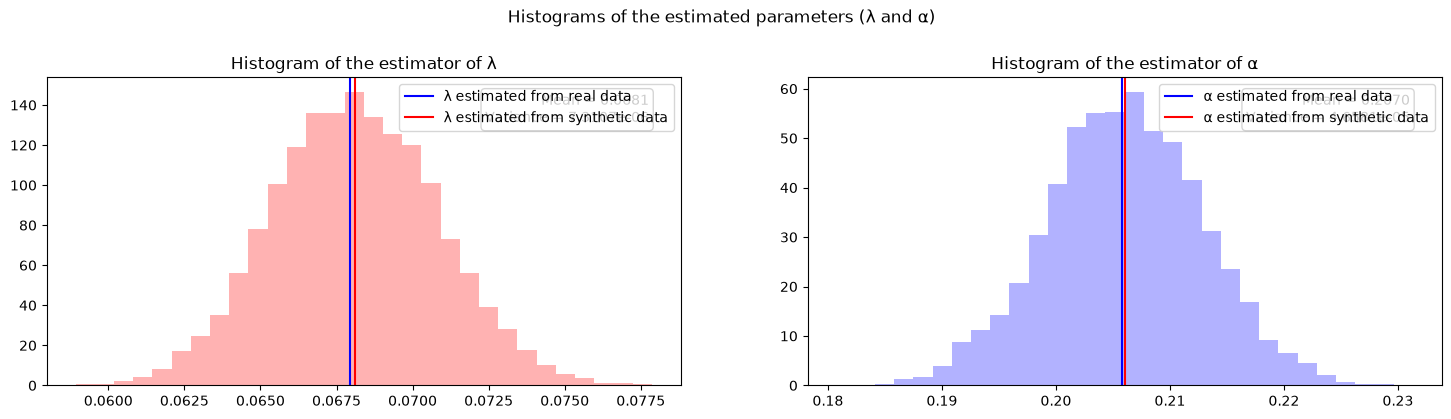

In [ ]:
# Let's start by generating a population of Gamma distributed numbers
N = 1_000_000 # Size of the population of Gamma distributed numbers 
            # (not given by the task, so it can be modified)
gamma_population = rng.gamma(shape=pop_alpha, scale=1/pop_lambda, size=N)
gamma_pop_mean, gamma_pop_std = np.mean(gamma_population), np.std(gamma_population)

# We'll now sample from the Gamma distribution, as if we were obtaining
# new precipitation data
n = 10_000        # Sample size given by the task
n_trials = 8_000  # Number of samplings we'll perform (not given by the task, so it can be modified)

sample_lambdas = []
sample_alphas = []

for _ in range(n_trials):
    sample = np.random.choice(gamma_population, size=n, replace=True) # With replacement, since we are emulating a precipitation sampling
    
    # We now estimate λ and α
    sample_gamma_mean = sample.mean() 
    sample_gamma_var = sample.var(ddof=1) # Careful... like we said on Task 1, if we are dealing with a sample instead of a population, we use ddof=1

    sample_lambda = sample_gamma_mean/sample_gamma_var
    sample_alpha = (sample_gamma_mean**2)/sample_gamma_var

    # Append the estimates to a python list
    sample_lambdas.append(sample_lambda)
    sample_alphas.append(sample_alpha)

# Now we turn the list of estimates into numpy array (so matplotlib can use them!)
sample_lambdas = np.array(sample_lambdas)
sample_alphas = np.array(sample_alphas)

# =================================================== #
# Calculate the mean and variance of the estimators
mean_lambda = sample_lambdas.mean()
var_lambda = np.var(sample_lambdas, ddof=1) # Sample variance

mean_alpha = sample_alphas.mean()
var_alpha = np.var(sample_alphas, ddof=1) # Sample variance

# Print the parameters estimated from the real data and the mean obtained from the synthetic data
print(f"Population λ: {pop_lambda:.4f}, Estimated λ: {mean_lambda:.4f}")
print(f"Population α: {pop_alpha:.4f}, Estimated α: {mean_alpha:.4f}")

# Histogram of the estimator of λ and α
# (code looks complicated, but it's the same. I just repeated it for the two figures instead of looping)
fig, axes = plt.subplots(1, 2, figsize=(18, 4))
axes[0].hist(sample_lambdas, bins=30, density=True, alpha=0.3, color="red")
axes[0].set_title("Histogram of the estimator of λ")
axes[0].text(
    0.95, 0.95,
    f"Mean = {mean_lambda:.4f}\nVariance = {var_lambda:.4e}",
    transform=axes[0].transAxes,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
axes[0].axvline(pop_lambda, color="blue", label=r"λ estimated from real data")
axes[0].axvline(mean_lambda, color="red", label=r"λ estimated from synthetic data")
axes[0].legend()

axes[1].hist(sample_alphas, bins=30, density=True, alpha=0.3, color="blue")
axes[1].set_title("Histogram of the estimator of α")
axes[1].text(
    0.95, 0.95,
    f"Mean = {mean_alphas:.4f}\nVariance = {var_alpha:.4e}",
    transform=axes[1].transAxes,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
axes[1].axvline(pop_alpha, color="blue", label=r"α estimated from real data")
axes[1].axvline(mean_alpha, color="red", label=r"α estimated from synthetic data")
axes[1].legend()

plt.suptitle('Histograms of the estimated parameters (λ and α)', y=1.05)
plt.show()

Original estimate of λ: 0.067933
Bootstrap mean of λ estimator: 0.068033
Bootstrap variance of λ estimator: 7.802900e-06

Original estimate of α: 0.205798
Bootstrap mean of α estimator: 0.206119
Bootstrap variance of α estimator: 4.962456e-05


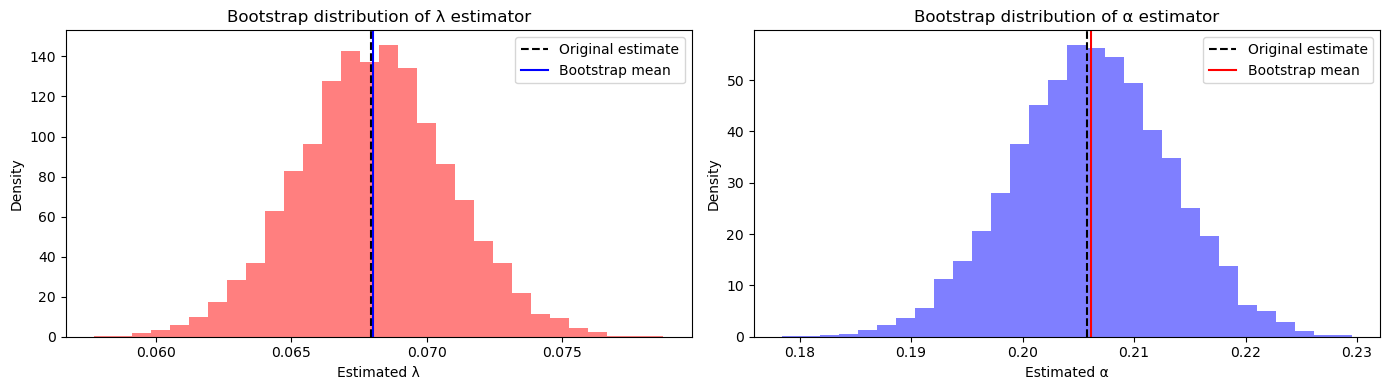

In [13]:
# We fix the seed to 42 in orden to have reproducibility
rng = np.random.default_rng(42)

n = 10_000       # Size of each bootstrap sample
n_trials = 8_000 # Number of bootstrap replications (we fix this number since it is not given)

sample_lambdas = np.empty(n_trials)
sample_alphas = np.empty(n_trials)

for i in range(n_trials):
    # Generate one sample directly from the fitted Gamma distribution
    sample = rng.gamma(shape=pop_alpha, scale=1 / pop_lambda, size=n)

    # Apply the same method-of-moments estimators as for the original data (we use s^2, not s_c^2)
    sample_mean = sample.mean()
    sample_var = sample.var(ddof=0)

    sample_lambdas[i] = sample_mean / sample_var
    sample_alphas[i] = sample_mean**2 / sample_var

# Bootstrap estimates of the mean and variance of the estimators
mean_lambda = sample_lambdas.mean()
var_lambda = sample_lambdas.var(ddof=1)

mean_alpha = sample_alphas.mean()
var_alpha = sample_alphas.var(ddof=1)

print(f"Original estimate of λ: {pop_lambda:.6f}")
print(f"Bootstrap mean of λ estimator: {mean_lambda:.6f}")
print(f"Bootstrap variance of λ estimator: {var_lambda:.6e}")
print()

print(f"Original estimate of α: {pop_alpha:.6f}")
print(f"Bootstrap mean of α estimator: {mean_alpha:.6f}")
print(f"Bootstrap variance of α estimator: {var_alpha:.6e}")

# Histograms of the bootstrap distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(sample_lambdas,bins=30,density=True,alpha=0.5,color="red")
axes[0].axvline(pop_lambda,color="black",linestyle="--",label="Original estimate")
axes[0].axvline(mean_lambda,color="blue",label="Bootstrap mean")
axes[0].set_title("Bootstrap distribution of λ estimator")
axes[0].set_xlabel("Estimated λ")
axes[0].set_ylabel("Density")
axes[0].legend()

axes[1].hist(sample_alphas,bins=30,density=True,alpha=0.5,color="blue")
axes[1].axvline(pop_alpha,color="black",linestyle="--",label="Original estimate")
axes[1].axvline(mean_alpha,color="red",label="Bootstrap mean")
axes[1].set_title("Bootstrap distribution of α estimator")
axes[1].set_xlabel("Estimated α")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

Population λ: 0.0679, Estimated λ: 0.0681
,Population α: 0.2058, Estimated α: 0.2060


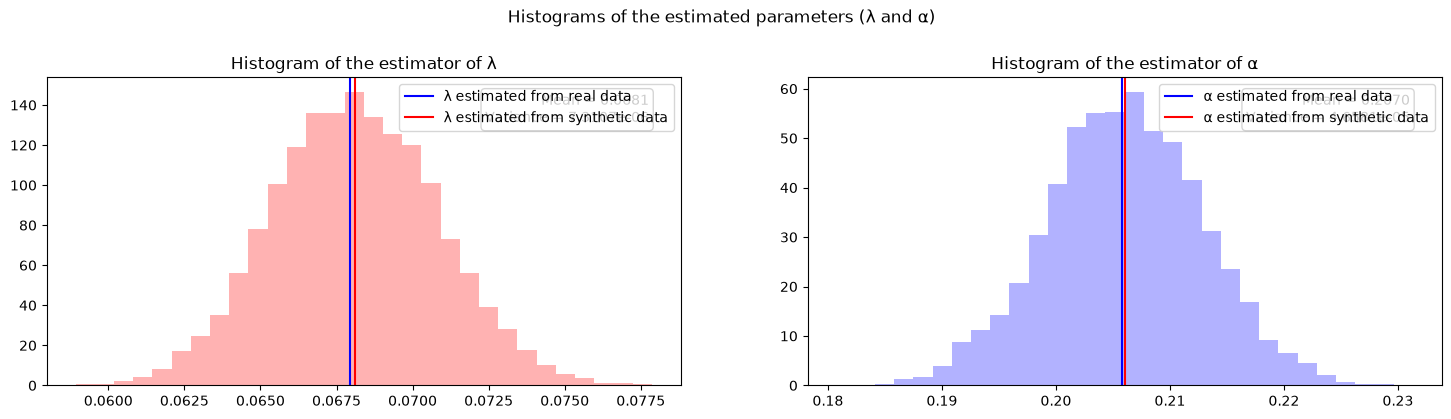

In [ ]:
# Let's start by generating a population of Gamma distributed numbers
N = 1_000_000 # Size of the population of Gamma distributed numbers 
            # (not given by the task, so it can be modified)
gamma_population = rng.gamma(shape=pop_alpha, scale=1/pop_lambda, size=N)
gamma_pop_mean, gamma_pop_std = np.mean(gamma_population), np.std(gamma_population)

# We'll now sample from the Gamma distribution, as if we were obtaining
# new precipitation data
n = 10_000        # Sample size given by the task
n_trials = 8_000  # Number of samplings we'll perform (not given by the task, so it can be modified)

sample_lambdas = []
sample_alphas = []

for _ in range(n_trials):
    sample = np.random.choice(gamma_population, size=n, replace=True) # With replacement, since we are emulating a precipitation sampling
    
    # We now estimate λ and α
    sample_gamma_mean = sample.mean() 
    sample_gamma_var = sample.var(ddof=1) # Careful... like we said on Task 1, if we are dealing with a sample instead of a population, we use ddof=1

    sample_lambda = sample_gamma_mean/sample_gamma_var
    sample_alpha = (sample_gamma_mean**2)/sample_gamma_var

    # Append the estimates to a python list
    sample_lambdas.append(sample_lambda)
    sample_alphas.append(sample_alpha)

# Now we turn the list of estimates into numpy array (so matplotlib can use them!)
sample_lambdas = np.array(sample_lambdas)
sample_alphas = np.array(sample_alphas)

# =================================================== #
# Calculate the mean and variance of the estimators
mean_lambda = sample_lambdas.mean()
var_lambda = np.var(sample_lambdas, ddof=1) # Sample variance

mean_alpha = sample_alphas.mean()
var_alpha = np.var(sample_alphas, ddof=1) # Sample variance

# Print the parameters estimated from the real data and the mean obtained from the synthetic data
print(f"Population λ: {pop_lambda:.4f}, Estimated λ: {mean_lambda:.4f}")
print(f"Population α: {pop_alpha:.4f}, Estimated α: {mean_alpha:.4f}")

# Histogram of the estimator of λ and α
# (code looks complicated, but it's the same. I just repeated it for the two figures instead of looping)
fig, axes = plt.subplots(1, 2, figsize=(18, 4))
axes[0].hist(sample_lambdas, bins=30, density=True, alpha=0.3, color="red")
axes[0].set_title("Histogram of the estimator of λ")
axes[0].text(
    0.95, 0.95,
    f"Mean = {mean_lambda:.4f}\nVariance = {var_lambda:.4e}",
    transform=axes[0].transAxes,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
axes[0].axvline(pop_lambda, color="blue", label=r"λ estimated from real data")
axes[0].axvline(mean_lambda, color="red", label=r"λ estimated from synthetic data")
axes[0].legend()

axes[1].hist(sample_alphas, bins=30, density=True, alpha=0.3, color="blue")
axes[1].set_title("Histogram of the estimator of α")
axes[1].text(
    0.95, 0.95,
    f"Mean = {mean_alphas:.4f}\nVariance = {var_alpha:.4e}",
    transform=axes[1].transAxes,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
axes[1].axvline(pop_alpha, color="blue", label=r"α estimated from real data")
axes[1].axvline(mean_alpha, color="red", label=r"α estimated from synthetic data")
axes[1].legend()

plt.suptitle('Histograms of the estimated parameters (λ and α)', y=1.05)
plt.show()

### Task 5

<span style="color:orange">***EN PROCESO***</span>

<span style="color:red">***TODO: Rellenar y hacer código***</span>

$$
1 - \alpha = 0.95 \implies \alpha = 0.005
$$

In [80]:
alpha_ci = 0.005

## Bayesian Inference Analysis

We now proceed to a Bayesian inference analysis:
  1. Find an implicit expression to find the parameters $\lambda$ and $\nu$ of the Gamma distribution using the Maximum likelihood approach. 
  2. Solve these equations and compare their value to the method of moments.
  3. Let's assume that we fix $\lambda$ to the value obtained in the method of moments. Using a uniform prior for $\nu \in [0,20]$, compute and plot the posterior distribution of $\nu$.

### Task 1

<span style="color:orange">***EN PROCESO***</span>

<span style="color:red">***TODO: Cambiar lambda por nu, que es la letra que quiere el profe***</span>


Let's start by formulating the log-likelihood function for $n$ samples:

$$
\begin{align*}
\ell(\alpha, \lambda) &= \frac{1}{n}\sum_{i=1}^n \log p(x_i \lvert \alpha, \lambda)\\
&= \frac{1}{n}\sum_{i=1}^n \log \left(x_i^{\alpha - 1} \frac{\lambda^\alpha \mathrm{e}^{-\lambda x_i}}{\Gamma(\alpha)} \right)\\
&= \frac{1}{n}\sum_{i=1}^n \Bigg[ \log(x_i^{\alpha - 1}) + \log \left(\frac{\lambda^\alpha \mathrm{e}^{-\lambda x_i}}{\Gamma(\alpha)} \right) \Bigg]\\
&= \frac{1}{n}\sum_{i=1}^n \Bigg[ (\alpha - 1)\log(x_i) + \alpha \log(\lambda) - \lambda x_i - \log\big(\Gamma(\alpha)\big) \Bigg]\\
&= \Bigg(\frac{(\alpha - 1)}{n}\sum_{i=1}^n log(x_i)\Bigg) + \alpha \log(\lambda) - \lambda \hat{\mu} - \log\big(\Gamma(\alpha)\big),
\end{align*}
$$

then, defining $\gamma_n = \frac{1}{n}\sum_{i=1}^n \log(x_i)$, we have:

$$
\ell(\alpha, \lambda) = (\alpha - 1)\gamma_n + \alpha \log(\lambda) - \lambda \hat{\mu} - \log\big(\Gamma(\alpha)\big)
$$

<span style="color:red">***TODO: Continuar. Ahora tocaría derivar, ver monotonía, bla bla... Incluso justificar por qué hemos escogido log en vez de la no-log***</span>

### Task 2

<span style="color:orange">***EN PROCESO***</span>

<span style="color:red">***TODO: Rellenar y hacer código***</span>

### Task 3

<span style="color:orange">***EN PROCESO***</span>

<span style="color:red">***TODO: Rellenar y hacer código***</span>

## Part II: Mining

We now pass to the study of a different dataset about the number of accidents occurring each year in mines (in UK).

number of points =  (112,)


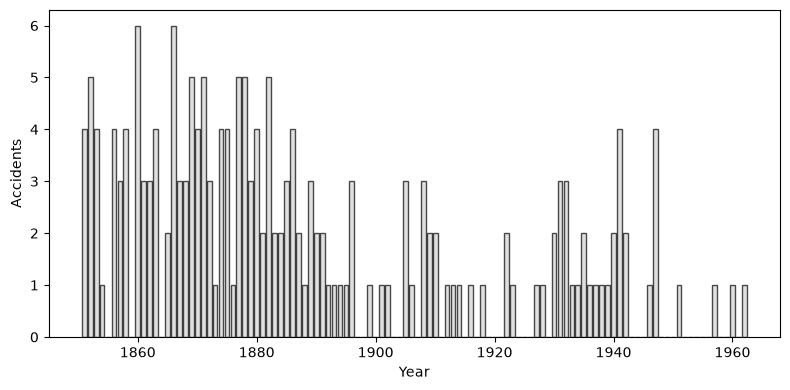

In [83]:

data = pd.read_csv('coal.csv')
X = data['Count'].to_numpy()
print("number of points = ",X.shape)
years = np.arange(1851, 1962+1)

plt.figure(figsize=(8,4))
plt.bar(years, X, color='lightgray', edgecolor='k', alpha=0.7)
plt.xlabel("Year"); plt.ylabel("Accidents")
#plt.legend(); 
plt.tight_layout();

We first consider the modelization of such even by a Poisson distribution 
$$
p(k) = \frac{\lambda^{k}}{k!} \exp(-\lambda)
$$
1. Compute the Fisher Information $I(\lambda) = \mathbb{E}\left[\left(\frac{\partial}{\partial \lambda} \log p_{\lambda}(k)\right)^2 \right]$.
2. Compute the MLE $\hat{\lambda}$ of the parameter $\lambda$ on the data, and give the estimate of the standard error for the estimator.
3. Using the value $\hat{\lambda}$, plot a sequence of $n=112$ random Poisson number and compare it to the data. Do you notice something ?


There seems to be a ceasure in the series at some point. We will try to modelize it using a Poisson distribution where the parameter $\lambda(t)$ will depend on the time we consider:
$$
\lambda(t) = \left\{ \begin{array}{c} \lambda_1 \text{ if } t<t_* \\ \lambda_2 \text{ if } t>t_*  \end{array}\right.
$$
We now will use only the likelihood of the model. In order to find the best value of $t_*$, 
1. Make list (numpy array) of all possible values of $t_*$
2. For each possible value of $t_*$, first compute the estimate of $(\lambda_1,\lambda_2)$ and compute the value of the likelihood.
3. Then select the value of $t_*$ that maximizes the likelihood.
4. Fixing the estimate of $(\hat{\lambda_1},\hat{\lambda_2})$, ans assuming that a prior $p(t_*)$ is uniform in the range $I_t = [1880,1920]$, make a graphics of the distribution $p(t_*|X)$

### Task 1

<span style="color:green">***ACABADA***</span>

<span style="color:red">***TODO: Añadir prosa***</span>

$$
\begin{align*}
&p_\lambda(k) = \frac{\lambda^{-k}}{k!}\mathrm{e}^{-\lambda}\\
\implies& \log p_\lambda(k) = \log\left(\frac{\lambda^k}{k!}\right) - \lambda = k\log(\lambda) - \log(k!) - \lambda\\
\implies& \frac{\partial}{\partial \lambda} \log p_\lambda(k) = \frac{k}{\lambda} - 1\\
\implies& \left(\frac{\partial}{\partial \lambda} \log p_\lambda(k) \right)^2 = \frac{k^2}{\lambda^2} - \frac{2k}{\lambda} + 1.
\end{align*}
$$

It's kind of *fastidioso* to calculate $\mathbb{E}\left[(\partial_\lambda \log p_\lambda(k))^2\right]$, so we can use what we learned in class:

$$
\mathbb{E}\left[\left(\frac{\partial}{\partial \lambda} \log p_{\lambda}(k)\right)^2 \right] = -\mathbb{E}\left[\frac{\partial^2}{\partial \lambda^2} \log p_{\lambda}(k) \right],
$$

and since

$$
\frac{\partial^2}{\partial \lambda^2} \log p_{\lambda}(k) = -\frac{k}{\lambda^2},
$$

we have:

$$
\begin{align*}
\mathbb{E}\left[\left(\frac{\partial}{\partial \lambda} \log p_{\lambda}(k)\right)^2 \right] &= -\mathbb{E}\left[\frac{\partial^2}{\partial \lambda^2} \log p_{\lambda}(k) \right]\\
&=- \left(-\frac{1}{\lambda^2}\right)\int_\mathbb{R} k p_\lambda(k) dk\\
&= \frac{1}{\lambda^2} \mathbb{E}[X] \text{ (where } X \text{ is a Poisson variable)}\\
&= \lambda^{-2} \lambda\\
&= \lambda^{-1}.
\end{align*}
$$

Therefore, the Fisher information $I(\lambda)$ is

$$
I(\lambda) = \frac{1}{\lambda}
$$

In [81]:
# No code for this task ;)

### Task 2

<span style="color:orange">***EN PROCESO***</span>

<span style="color:red">***TODO: Añadir prosa***</span>

We have that the MLE estimator for $\lambda$ can be obtained as follows (using the log-likelihood function):

$$
\begin{align*}
\ell(\lambda) &= \frac{1}{n} \sum_{i=1}^n \log p_\lambda(k_i)\\
&= \frac{1}{n} \sum_{i=1}^n \left[k_i \log(\lambda) - \log(k_i!) - \lambda \right]\\
&= \log(\lambda) \left(\frac{1}{n}\sum_{i=1}^2 k \right) - \left(\frac{1}{n}\sum_{i=1}^n \log(k_i!)\right) - \lambda\\
&= \log(\lambda) \hat{\mu} - \left(\frac{1}{n}\sum_{i=1}^n \log(k_i!)\right) - \lambda.
\end{align*}
$$

Computing the derivative with respect to $\lambda$ we obtain:

$$
\frac{\partial}{\partial \lambda} \ell(\lambda) = \frac{\hat{\mu}}{\lambda} - 1,
$$

and we have a critical point of $\ell$ if and only if:

$$
\frac{\partial}{\partial \lambda} \ell(\lambda) = \frac{\hat{\mu}}{\lambda} - 1 = 0 \iff \lambda = \hat{\mu}.
$$

Therefore,

$$
\hat{\lambda}_{MLE} = \hat{\mu}
$$

In [85]:
# As we've seen in the Jupyter cell from before, we just need to compute the population mean to estimate λ

In [ ]:
# Hola esto es un cambio :)